In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, auc

In [2]:
df = pd.read_csv('D:\DEV VELLY\Datasets\diabetes.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_14840\2081346105.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\DEV VELLY\Datasets\diabetes.csv')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(768, 9)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
X = df.iloc[:, 0:-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=40)

In [8]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [9]:
model_logistic = LogisticRegression(C=2)
model_logistic.fit(X_train, y_train)

y_perd_logistic = model_logistic.decision_function(X_test)

In [10]:
dt = DecisionTreeClassifier(max_depth = 50)
dt.fit(X_train, y_train)
#
y_pred_dt = dt.predict_proba(X_test)

In [11]:
rfr = RandomForestClassifier(n_estimators=100)
rfr.fit(X_train, y_train)

y_pred_rfr = rfr.predict_proba(X_test)


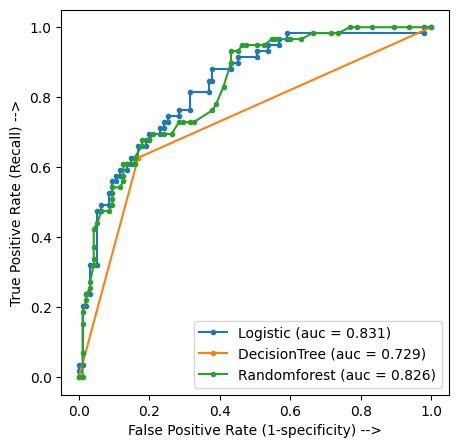

In [12]:
logistic_fpr, logistic_tpr, threshold = roc_curve(y_test, y_perd_logistic)
auc_logistic = auc(logistic_fpr, logistic_tpr)

dt_fpr, dt_tpr, threshold = roc_curve(y_test, y_pred_dt[:, 1:2])
auc_dt = auc(dt_fpr, dt_tpr)

rfr_fpr, rfr_tpr, threshold = roc_curve(y_test, y_pred_rfr[:,1:2])
auc_rfr = auc(rfr_fpr, rfr_tpr)

plt.figure(figsize=(5, 5), dpi = 100)
plt.plot(logistic_fpr, logistic_tpr, marker = '.', label = 'Logistic (auc = %0.3f)' % auc_logistic)
plt.plot(dt_fpr, dt_tpr, marker = '.', label = 'DecisionTree (auc = %0.3f)' % auc_dt)
plt.plot(rfr_fpr, rfr_tpr, marker = '.', label = 'Randomforest (auc = %0.3f)' % auc_rfr)

plt.xlabel('False Positive Rate (1-specificity) -->')
plt.ylabel('True Positive Rate (Recall) -->')

plt.legend()
plt.show()

In [13]:
from sklearn.metrics import confusion_matrix

cnf = confusion_matrix(y_test, y_pred_rfr)
cnf

ValueError: Classification metrics can't handle a mix of binary and continuous-multioutput targets